In [9]:
import sys
!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install opencv-python numpy matplotlib

In [10]:
# -----------------------------
# IPCV 2026 Homework — Step 0
# Load two images (same camera) of a static 3D scene.
# We work in both:
#   - BGR (for drawing/visualization with OpenCV)
#   - grayscale (for SIFT feature extraction)
# -----------------------------

import cv2
import numpy as np
import matplotlib.pyplot as plt

def read_image_bgr_and_gray(path: str):
    """
    Reads an image from disk.

    Returns:
      img_bgr  : color image (OpenCV default format: BGR)
      img_gray : grayscale image (needed for SIFT, which usually works on intensity)
    """
    img_bgr = cv2.imread(path)
    if img_bgr is None:
        raise FileNotFoundError(f"Could not read image at: {path}")
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    return img_bgr, img_gray

# --- YOUR IMAGE PATHS ---
img1_path = "/content/drive/MyDrive/Computer_Vision_2026/Project_clean/photo1.png"
img2_path = "/content/drive/MyDrive/Computer_Vision_2026/Project_clean/photo2.png"

img1_bgr, img1_gray = read_image_bgr_and_gray(img1_path)
img2_bgr, img2_gray = read_image_bgr_and_gray(img2_path)

print("Image 1 shape (H,W,C):", img1_bgr.shape)
print("Image 2 shape (H,W,C):", img2_bgr.shape)

AttributeError: partially initialized module 'cv2' has no attribute 'dnn' (most likely due to a circular import)

Keypoints img1: 27550
Keypoints img2: 29196
Good matches after ratio test: 790


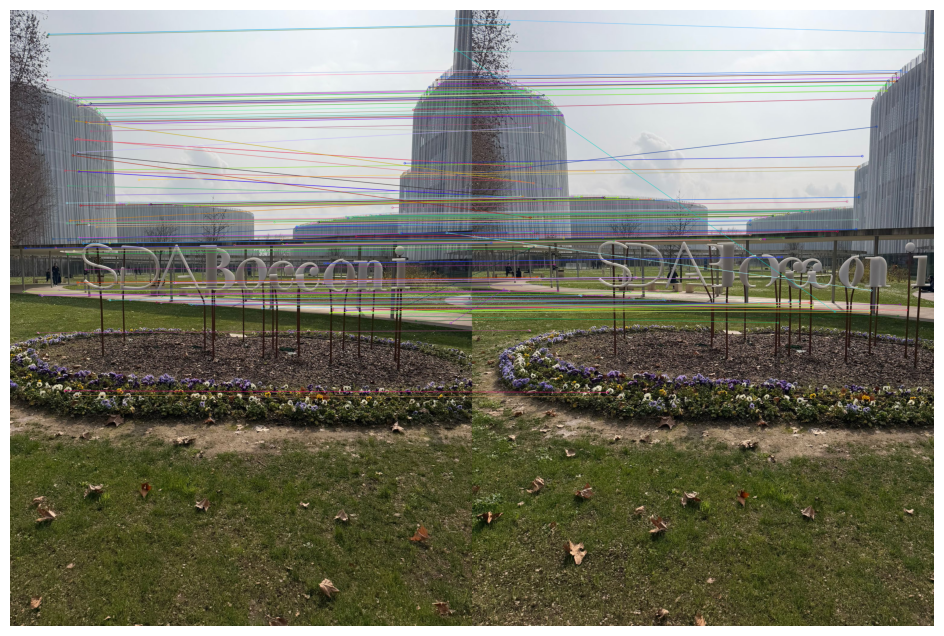

In [ ]:
# -----------------------------
# IPCV 2026 Homework — Step 1
# Feature extraction & matching (SIFT + Lowe ratio test)
#
# Goal:
#   Find candidate correspondences between the two images:
#     x_i  <->  x'_i
#
# Why SIFT?
#   SIFT detects repeatable local features (corners/blobs) and describes them
#   with vectors that can be matched across viewpoints.
#
# Why the ratio test?
#   It removes ambiguous matches by keeping a match only if the best match
#   is significantly better than the second best one (Lowe's criterion).
# -----------------------------

import cv2
import numpy as np
import matplotlib.pyplot as plt

def sift_ratio_matches(img1_gray, img2_gray, ratio=0.75, max_draw=200):
    """
    Args:
      img1_gray, img2_gray: grayscale images
      ratio               : Lowe ratio threshold (typical: 0.7–0.8)
      max_draw            : how many matches to draw for visualization

    Returns:
      kp1, kp2            : SIFT keypoints
      good_matches        : list of cv2.DMatch passing ratio test
      pts1, pts2          : matched points as (N,2) float arrays (pixel coords)
      matches_to_draw     : subset of matches for plotting
    """
    sift = cv2.SIFT_create()

    # Detect keypoints and compute descriptors
    kp1, des1 = sift.detectAndCompute(img1_gray, None)
    kp2, des2 = sift.detectAndCompute(img2_gray, None)

    if des1 is None or des2 is None:
        raise RuntimeError("SIFT could not find descriptors in one of the images.")

    # KNN matching (k=2) so we can apply the ratio test
    bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)
    knn = bf.knnMatch(des1, des2, k=2)

    # Lowe ratio test
    good = []
    for m, n in knn:
        if m.distance < ratio * n.distance:
            good.append(m)

    # Sort matches by descriptor distance (lower is better)
    good = sorted(good, key=lambda m: m.distance)

    # Convert match objects to point coordinates
    pts1 = np.float32([kp1[m.queryIdx].pt for m in good])  # (x,y) in image 1
    pts2 = np.float32([kp2[m.trainIdx].pt for m in good])  # (x,y) in image 2

    matches_to_draw = good[:min(len(good), max_draw)]
    return kp1, kp2, good, pts1, pts2, matches_to_draw

def show_matches(img1_bgr, img2_bgr, kp1, kp2, matches):
    """Draw and display feature matches."""
    vis = cv2.drawMatches(
        img1_bgr, kp1, img2_bgr, kp2, matches, None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )
    plt.figure(figsize=(16, 8))
    plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

# Run matching
kp1, kp2, good_matches, pts1, pts2, matches_to_draw = sift_ratio_matches(
    img1_gray, img2_gray, ratio=0.75, max_draw=200
)

print(f"Keypoints img1: {len(kp1)}")
print(f"Keypoints img2: {len(kp2)}")
print(f"Good matches after ratio test: {len(good_matches)}")

# Visualize a subset of matches
show_matches(img1_bgr, img2_bgr, kp1, kp2, matches_to_draw)

Estimated F (OpenCV RANSAC):
 [[-1.58133991e-08 -1.55448941e-06 -1.78272509e-04]
 [ 1.90048091e-06  6.01347874e-08  2.85748274e-02]
 [-7.88889707e-06 -2.92199967e-02  1.00000000e+00]]
Inliers after RANSAC: 443 / 790 (56.1%)


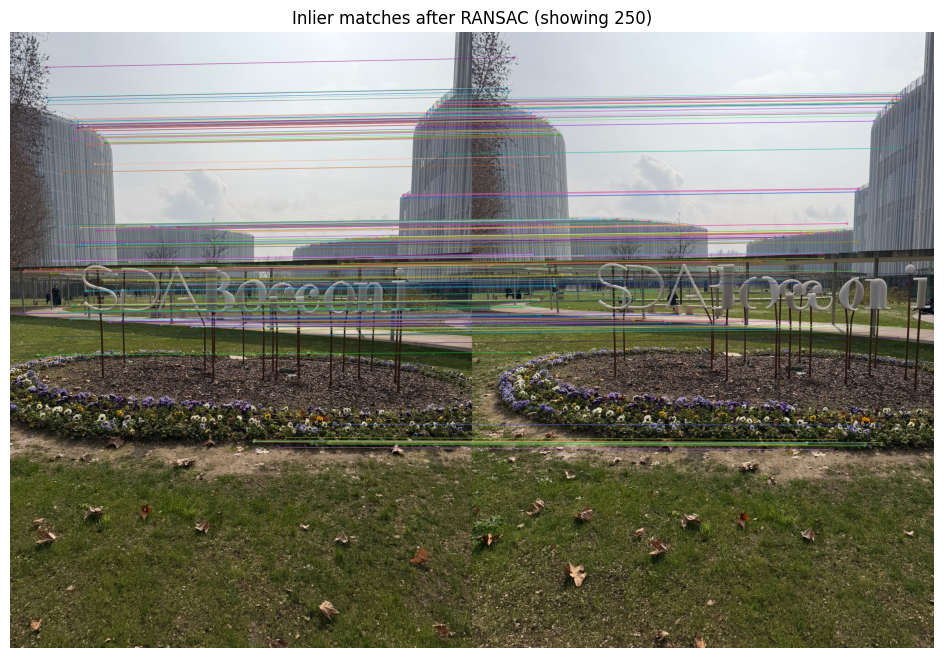

In [ ]:
# -----------------------------
# IPCV 2026 Homework — Step 2
# Robustly filter matches with RANSAC by estimating the Fundamental matrix F.
#
# Why F here?
#   At this stage we only have pixel coordinates. F models epipolar geometry
#   in pixel space and allows us to remove outlier matches.
#
# Output:
#   - F_cv: Fundamental matrix estimated by RANSAC
#   - inlier_mask: boolean mask selecting inlier correspondences
#   - pts1_in, pts2_in: inlier point coordinates
# -----------------------------

import cv2
import numpy as np
import matplotlib.pyplot as plt

def estimate_F_ransac(pts1, pts2, reproj_thresh=1.0, confidence=0.999):
    """
    Estimates Fundamental matrix using RANSAC.

    Args:
      reproj_thresh: inlier threshold (in pixels, OpenCV's internal measure)
      confidence   : desired probability of success

    Returns:
      F (3x3), inlier_mask (N,) boolean
    """
    F, mask = cv2.findFundamentalMat(
        pts1, pts2,
        method=cv2.FM_RANSAC,
        ransacReprojThreshold=reproj_thresh,
        confidence=confidence
    )
    if F is None or mask is None:
        raise RuntimeError("cv2.findFundamentalMat failed. Try changing reproj_thresh.")
    inlier_mask = mask.ravel().astype(bool)
    return F, inlier_mask

# Try 0.5, 1.0, 2.0 if needed
F_cv, inlier_mask = estimate_F_ransac(pts1, pts2, reproj_thresh=1.0)

pts1_in = pts1[inlier_mask]
pts2_in = pts2[inlier_mask]

print("Estimated F (OpenCV RANSAC):\n", F_cv)
print(f"Inliers after RANSAC: {pts1_in.shape[0]} / {pts1.shape[0]} ({pts1_in.shape[0]/pts1.shape[0]:.1%})")

def show_inlier_matches(img1_bgr, img2_bgr, kp1, kp2, good_matches, inlier_mask, max_draw=250):
    """
    Visualize only the inlier matches retained by RANSAC.
    """
    inlier_matches = [m for m, keep in zip(good_matches, inlier_mask) if keep]
    inlier_matches = sorted(inlier_matches, key=lambda m: m.distance)[:max_draw]

    vis = cv2.drawMatches(
        img1_bgr, kp1, img2_bgr, kp2, inlier_matches, None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )
    plt.figure(figsize=(16, 8))
    plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title(f"Inlier matches after RANSAC (showing {len(inlier_matches)})")
    plt.show()

show_inlier_matches(img1_bgr, img2_bgr, kp1, kp2, good_matches, inlier_mask)

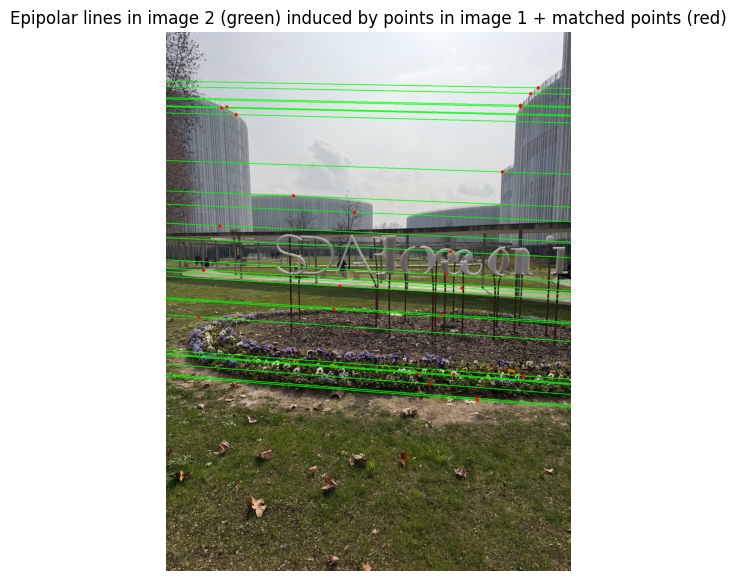

In [ ]:
# -----------------------------
# IPCV 2026 Homework — Step 3
# Visual check of epipolar geometry:
# For each point x in image 1, compute the corresponding epipolar line l' in image 2:
#   l' = F x
# and verify that the matched point x' lies on/near l'.
# -----------------------------

import numpy as np
import cv2
import matplotlib.pyplot as plt

def draw_epipolar_lines_in_img2(img2_bgr, F, pts1, pts2, n=20, seed=0):
    """
    Draw epipolar lines in image 2 induced by points in image 1.

    Args:
      img2_bgr: image 2 (BGR)
      F       : fundamental matrix (3x3)
      pts1    : inlier points in image 1 (N,2)
      pts2    : corresponding inlier points in image 2 (N,2)
      n       : number of random correspondences to visualize
    """
    rng = np.random.default_rng(seed)
    img2_vis = img2_bgr.copy()
    h, w = img2_vis.shape[:2]

    N = pts1.shape[0]
    idx = rng.choice(N, size=min(n, N), replace=False)

    p1 = pts1[idx].reshape(-1, 1, 2)  # OpenCV expects (N,1,2)
    p2 = pts2[idx]                    # (N,2)

    # Compute epipolar lines in image 2 for points from image 1
    lines2 = cv2.computeCorrespondEpilines(p1, 1, F)  # 1 means points are in image 1
    lines2 = lines2.reshape(-1, 3)                    # each line: a x + b y + c = 0

    for (a, b, c), (x2, y2) in zip(lines2, p2):
        # Compute two points on the line inside the image borders
        if abs(b) > 1e-9:
            x0, y0 = 0, int(-c / b)
            x1, y1 = w, int(-(c + a * w) / b)
        else:
            # Vertical line case (rare)
            x0, y0 = int(-c / a), 0
            x1, y1 = int(-c / a), h

        # Draw epipolar line (green) and the matched point (red)
        cv2.line(img2_vis, (x0, y0), (x1, y1), (0, 255, 0), 2)
        cv2.circle(img2_vis, (int(x2), int(y2)), 6, (0, 0, 255), -1)

    plt.figure(figsize=(16, 7))
    plt.imshow(cv2.cvtColor(img2_vis, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title("Epipolar lines in image 2 (green) induced by points in image 1 + matched points (red)")
    plt.show()

# Use RANSAC inliers
draw_epipolar_lines_in_img2(img2_bgr, F_cv, pts1_in, pts2_in, n=25)

In [ ]:
# -----------------------------
# IPCV 2026 Homework — Step 4
# Camera calibration using a printed checkerboard (OpenCV).
#
# Output:
#   - K: intrinsic calibration matrix
#   - dist: distortion coefficients
#   - mean reprojection error (quality measure)
#
# IMPORTANT:
#   Use checkerboard photos taken with the SAME smartphone camera/lens mode
#   and ideally the SAME resolution as your scene images.
# -----------------------------

import cv2
import numpy as np
import glob
import os

# 1) Path to your checkerboard images
CHECKER_DIR = "/content/drive/MyDrive/Computer_Vision_2026/Project_1/checkerboard/"
img_paths = sorted(glob.glob(os.path.join(CHECKER_DIR, "*.jpg")) +
                   glob.glob(os.path.join(CHECKER_DIR, "*.jpeg")) +
                   glob.glob(os.path.join(CHECKER_DIR, "*.png")))

print("Checkerboard images found:", len(img_paths))
if len(img_paths) == 0:
    raise RuntimeError("No checkerboard images found. Check CHECKER_DIR and file extensions.")

# 2) Checkerboard pattern definition (INNER corners!)
# Example: if your printed board has 10x7 squares, inner corners are (9,6).
PATTERN_SIZE = (9, 6)   # (cols, rows) of inner corners — YOU MUST SET THIS CORRECTLY
SQUARE_SIZE = 0.025     # square size in meters (e.g., 2.5cm -> 0.025). Set your real printed size.

# Termination criteria for cornerSubPix refinement
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 1e-6)

# Prepare known 3D points for the checkerboard corners on Z=0 plane
objp = np.zeros((PATTERN_SIZE[0] * PATTERN_SIZE[1], 3), np.float32)
objp[:, :2] = np.mgrid[0:PATTERN_SIZE[0], 0:PATTERN_SIZE[1]].T.reshape(-1, 2)
objp *= SQUARE_SIZE  # scale to real-world size

objpoints = []  # list of (N,3) 3D points
imgpoints = []  # list of (N,2) 2D points

img_size = None
good_images = 0

for p in img_paths:
    img = cv2.imread(p)
    if img is None:
        continue
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    if img_size is None:
        img_size = (gray.shape[1], gray.shape[0])  # (W,H)

    # Detect checkerboard corners
    ret, corners = cv2.findChessboardCorners(
        gray, PATTERN_SIZE,
        flags=cv2.CALIB_CB_ADAPTIVE_THRESH + cv2.CALIB_CB_NORMALIZE_IMAGE
    )

    if not ret:
        continue

    # Refine corner locations to subpixel accuracy
    corners_refined = cv2.cornerSubPix(gray, corners, (11, 11), (-1, -1), criteria)

    objpoints.append(objp)
    imgpoints.append(corners_refined)
    good_images += 1

print("Images with detected corners:", good_images)
if good_images < 8:
    raise RuntimeError("Too few valid checkerboard detections. Aim for 10–20 good images.")

# Calibrate camera
ret, K, dist, rvecs, tvecs = cv2.calibrateCamera(
    objpoints, imgpoints, img_size, None, None
)

print("\nCalibration RMS reprojection error (OpenCV output):", ret)
print("\nIntrinsic matrix K:\n", K)
print("\nDistortion coefficients dist:\n", dist.ravel())

# Compute mean reprojection error manually (good for the report)
total_err = 0
total_points = 0

for i in range(len(objpoints)):
    projected, _ = cv2.projectPoints(objpoints[i], rvecs[i], tvecs[i], K, dist)
    projected = projected.reshape(-1, 2)
    observed = imgpoints[i].reshape(-1, 2)
    err = np.linalg.norm(observed - projected, axis=1).sum()
    total_err += err
    total_points += len(objpoints[i])

mean_reproj_error = total_err / total_points
print("\nMean reprojection error (pixels):", mean_reproj_error)

sa